Theory

ReAct (Reasoning + Acting) is a paradigm where the model interleaves Thought → Action → Observation cycles until reaching a final answer. Introduced by Yao et al. (2022), it grounds reasoning in real-world tool feedback.

Unlike pure CoT which reasons in isolation, ReAct can query external tools — web search, code execution, databases, APIs — and incorporate the results into subsequent reasoning. This prevents hallucination by grounding claims in verified information.

LangGraph is the ideal framework for ReAct because its cycle detection, tool integration, and conditional routing map exactly to the Thought–Action–Observation loop.

The ReAct Loop

Thought: Reason about what information is needed

Action: Call a tool with specific parameters

Observation: Incorporate tool result into context

Repeat: Until enough info to answer confidently

Final Answer: Synthesize all observations

Max Steps: Always set a ceiling to prevent loops

In [12]:
# ─────────────────────────────────────────────────────────
# ReAct Agent with LangGraph
# Pattern: Cyclical Thought → Action → Observation loop
# ─────────────────────────────────────────────────────────

from typing import TypedDict, Optional, Literal, Annotated
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langchain_core.messages import AIMessage, HumanMessage, ToolMessage
from langgraph.prebuilt import ToolNode
import operator, json, requests
from dotenv import load_dotenv
from IPython.display import Image, display
from langchain_community.tools.tavily_search import TavilySearchResults
from serpapi import GoogleSearch
load_dotenv()

import os

os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["SERPAPI_API_KEY"]=os.getenv("SERPAPI_API_KEY")

In [13]:
# ── Tool Definitions ──────────────────────────────────────
@tool
def web_search(query: str) -> str:
    """Search the web for current information about a topic."""
    tavily = TavilySearchResults(max_results=3)
    results = tavily.invoke(query)
    return str(results)

@tool
def python_repl(code: str) -> str:
    """Execute Python code and return the output. Use for ALL calculations.
    Always call this for any math. The result of the last expression is auto-captured.
    """
    import io, contextlib, ast, math
    output = io.StringIO()
    globs = {"__builtins__": __builtins__, "math": math}
    try:
        with contextlib.redirect_stdout(output):
            try:
                # Capture bare expressions (e.g. math.sqrt(1764))
                tree = ast.parse(code, mode="eval")
                result = eval(compile(tree, "<string>", "eval"), globs)
                if result is not None:
                    print(result)
            except SyntaxError:
                # Multi-line / statement code
                exec(code, globs)
        captured = output.getvalue().strip()
        return captured if captured else "Code executed (no output)"
    except Exception as e:
        return f"Error: {e}"

@tool
def get_weather(city: str) -> str:
    """Get current weather for a city."""
    
    params = {
        "engine": "google",
        "q": f"weather in {city}",
        "api_key": os.getenv("SERPAPI_API_KEY")
    }

    search = GoogleSearch(params)
    results = search.get_dict()

    weather = results.get("answer_box", {})
    
    if not weather:
        return f"Weather data not found for {city}"

    return (
        f"Weather in {city}: "
        f"{weather.get('temperature')}°C, "
        f"{weather.get('weather')}, "
        f"Humidity: {weather.get('humidity')}"
    )



TOOLS = [web_search, python_repl, get_weather]

In [14]:
# ── State Schema ──────────────────────────────────────────
class ReActState(TypedDict):
    messages: Annotated[list, operator.add]  # Message history
    question: str
    step_count: int
    max_steps: int
    tool_calls_made: list[str]
    final_answer: Optional[str]

In [15]:
# ── LLM with Tool Binding ─────────────────────────────────
llm = ChatOpenAI(model="gpt-4o", temperature=0.0)
llm_with_tools = llm.bind_tools(TOOLS)

In [16]:
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage

# ── Node 1: Reasoning (Thought + Action Selection) ────────
def reason_and_act(state: ReActState) -> ReActState:
    """
    The core ReAct node. The LLM sees the full message history
    and decides whether to:
    1. Call a tool
    2. Provide a final answer
    """

    system_prompt = """You are a ReAct agent. You MUST follow this strict protocol:

STRICT RULES — NO EXCEPTIONS:
1. NEVER compute math in your head. ALWAYS call python_repl for any calculation.
2. NEVER guess weather. ALWAYS call get_weather for any weather question.
3. NEVER call web_search unless explicitly asked for web/news info.
4. You may call MULTIPLE tools in a single step if needed.
5. After ALL tool results are back and you have everything you need, respond with:
   Final Answer: <your complete answer here>
6. DO NOT write "Action: ..." in text. Use actual tool calls instead.
7. DO NOT answer until you have real tool output for every sub-question.
"""

    # ✅ Use proper message objects
    messages = [
        SystemMessage(content=system_prompt),
        *state["messages"]
    ]

    # ✅ If at max steps, force a final answer without tools
    at_limit = state.get("step_count", 0) >= state.get("max_steps", 10) - 1
    if at_limit:
        from langchain_openai import ChatOpenAI
        llm_no_tools = ChatOpenAI(model="gpt-4o", temperature=0.0)
        messages_forced = messages + [
            SystemMessage(content="You have reached the maximum number of steps. Summarize what you know and provide a Final Answer now.")
        ]
        response = llm_no_tools.invoke(messages_forced)
    else:
        response = llm_with_tools.invoke(messages)

    # ✅ Safe tool call extraction (new format)
    tool_calls = []
    if hasattr(response, "tool_calls") and response.tool_calls:
        tool_calls = [tc.get("name") for tc in response.tool_calls]

    # ✅ Return only the DELTA (new message) — LangGraph reducer adds it automatically
    return {
        "messages": [response],
        "step_count": state.get("step_count", 0) + 1,
        "tool_calls_made": state.get("tool_calls_made", []) + tool_calls,
    }

In [17]:
# ── Node 2: Tool Execution (using prebuilt ToolNode) ──────
from langchain_core.messages import ToolMessage

def execute_tools(state: ReActState) -> ReActState:
    last_message = state["messages"][-1]

    if not hasattr(last_message, "tool_calls") or not last_message.tool_calls:
        return state

    tool_outputs = []

    for tc in last_message.tool_calls:
        tool_name = tc["name"]
        tool_args = tc.get("args", {})

        if tool_name == "python_repl":
            result = python_repl.invoke(tool_args)
        elif tool_name == "get_weather":
            result = get_weather.invoke(tool_args)
        elif tool_name == "web_search":
            result = web_search.invoke(tool_args)
        else:
            result = "Unknown tool"

        tool_outputs.append(
            ToolMessage(
                content=str(result),
                tool_call_id=tc["id"]
            )
        )

    # ✅ Return only the DELTA — LangGraph reducer appends automatically
    return {
        "messages": tool_outputs
    }

In [18]:
# ── Conditional Router ────────────────────────────────────
def should_continue(state: ReActState):
    # ✅ Guard: stop if max steps reached
    if state.get("step_count", 0) >= state.get("max_steps", 10):
        return "end"

    last_message = state["messages"][-1]

    # ✅ If LLM called tools → go to tool node
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return "tools"

    # ✅ Stop if final answer or no more tool calls
    return "end"

In [19]:
# ── Graph Construction ────────────────────────────────────
def build_react_graph():
    builder = StateGraph(ReActState)

    builder.add_node("reason_and_act", reason_and_act)
    builder.add_node("tools", execute_tools)

    builder.add_edge(START, "reason_and_act")
    builder.add_conditional_edges(
        "reason_and_act",
        should_continue,
        {"tools": "tools", "end": END}
    )
    builder.add_edge("tools", "reason_and_act")   # Observation → back to reasoning

    return builder.compile()

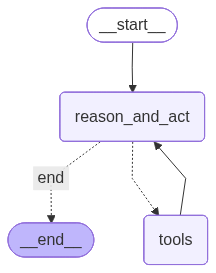

In [20]:
# ── Usage ─────────────────────────────────────────────────
graph = build_react_graph()

# View
display(Image(graph.get_graph().draw_mermaid_png()))



In [21]:
result = graph.invoke({
    "messages": [HumanMessage(content="What is the square root of 1764, and what's the weather in that many degrees Celsius in Tokyo?")],
    "question": "Math + weather query",
    "step_count": 0,
    "max_steps": 2,
    "tool_calls_made": [],
    "final_answer": None
})

print(f"Steps taken: {result['step_count']}")
print(f"Tools used: {result['tool_calls_made']}")
print(f"Final: {result['messages'][-1].content}")

Steps taken: 2
Tools used: ['python_repl', 'get_weather']
Final: The square root of 1764 is 42. The weather in Tokyo is currently 52°C with rain and 96% humidity. 

Final Answer: The square root of 1764 is 42. The weather in Tokyo at 42°C is not available, but currently, it is 52°C with rain and 96% humidity.
